🎬 Memulai Pelatihan RL dengan Multi-Trace (Generalization Mode)...
✅ Berhasil memuat 40 file trace dari folder 'traces/mahimahi'.
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 100      |
|    ep_rew_mean     | -282     |
| time/              |          |
|    fps             | 5223     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 100         |
|    ep_rew_mean          | -199        |
| time/                   |             |
|    fps                  | 3554        |
|    iterations           | 2           |
|    time_elapsed         | 1           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl  

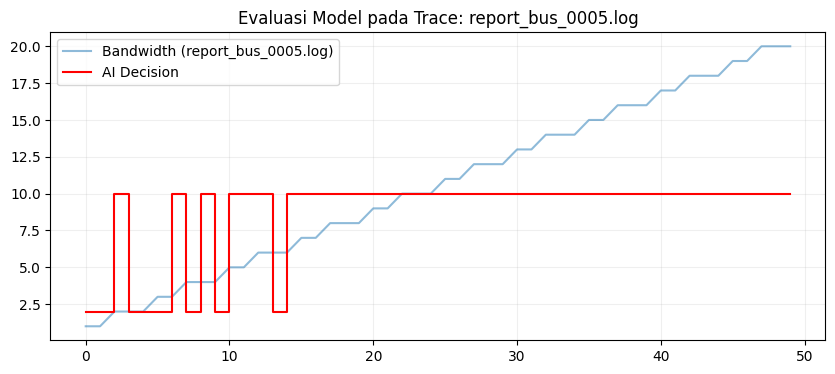

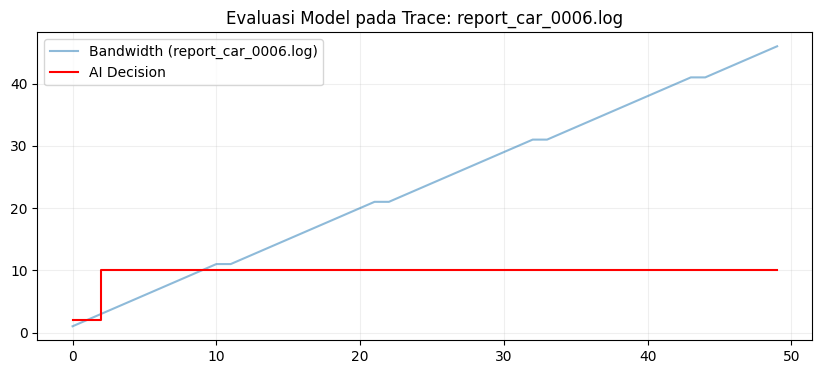

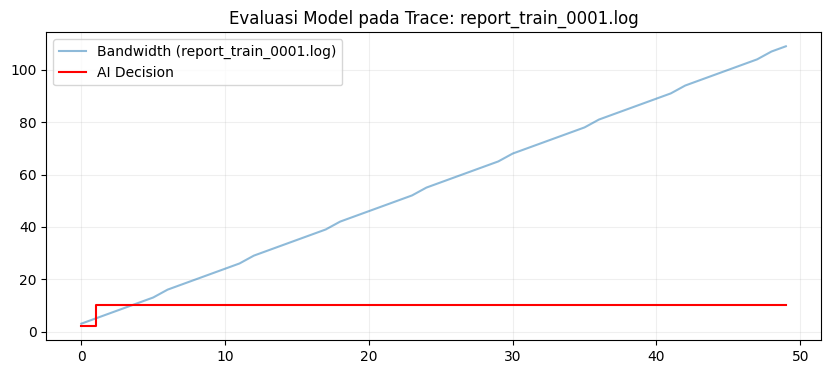

In [2]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
from stable_baselines3 import PPO
import matplotlib.pyplot as plt
import pandas as pd
from collections import deque
import os
import random

class MahimahiTraceManager:
    """
    Mengelola banyak file bandwidth dari sebuah folder.
    Sistem akan memilih satu trace secara acak setiap kali episode di-reset.
    """
    def __init__(self, folder_path=None):
        self.traces = []
        
        # Cek folder dan muat semua file .txt
        if folder_path and os.path.exists(folder_path):
            files = [f for f in os.listdir(folder_path) if f.endswith('.log')]
            for file in files:
                path = os.path.join(folder_path, file)
                with open(path, 'r') as f:
                    # Konversi isi file ke list of floats (Mbps)
                    data = [float(line.strip()) for line in f if line.strip()]
                    if data:
                        self.traces.append({
                            "name": file,
                            "data": data
                        })
            print(f"✅ Berhasil memuat {len(self.traces)} file trace dari folder '{folder_path}'.")

        # Jika folder kosong atau tidak ada, buat data sintetis sebagai cadangan
        if not self.traces:
            print("⚠️ Folder trace kosong. Membuat 3 pola sintetis (Stable, Volatile, Drop)...")
            t = np.linspace(0, 100, 1000)
            
            # Trace 1: Stabil Kencang
            self.traces.append({
                "name": "synthetic_stable",
                "data": np.clip(12 + np.random.normal(0, 0.5, 1000), 1, 20).tolist()
            })
            # Trace 2: Fluktuatif
            self.traces.append({
                "name": "synthetic_volatile",
                "data": np.clip(8 + 4 * np.sin(t * 0.2) + np.random.normal(0, 1, 1000), 1, 20).tolist()
            })
            # Trace 3: Sering Drop
            drop_data = np.clip(10 + np.random.normal(0, 1, 1000), 1, 20)
            drop_data[200:400] = 1.0 # Drop parah di tengah
            self.traces.append({
                "name": "synthetic_drops",
                "data": drop_data.tolist()
            })

        self.active_trace = None
        self.ptr = 0

    def select_random_trace(self):
        """Memilih satu trace secara acak untuk sesi latihan ini"""
        self.active_trace = random.choice(self.traces)
        self.ptr = 0
        return self.active_trace["name"]

    def get_next_bandwidth(self):
        if not self.active_trace:
            self.select_random_trace()
        
        val = self.active_trace["data"][self.ptr]
        self.ptr = (self.ptr + 1) % len(self.active_trace["data"])
        return val

class TandonMahimahiEnv(gym.Env):
    """
    Simulator Lingkungan berbasis Multi-Trace Jaringan.
    """
    def __init__(self, trace_manager):
        super(TandonMahimahiEnv, self).__init__()
        self.trace_manager = trace_manager
        self.bitrates = [0.5, 2.5, 8.0] # Mbps (Action 0, 1, 2)
        
        # State: [Buffer, Throughput, LastAction, Buffer_Trend, TP_Trend, RTT, Dropped]
        self.observation_space = spaces.Box(
            low=np.array([0, 0, 0, -5, -5, 0, 0]),
            high=np.array([30, 20, 2, 5, 5, 1000, 100]),
            dtype=np.float32
        )
        self.action_space = spaces.Discrete(3)
        
        self.state = None
        self.max_steps = 100
        self.current_step = 0

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        
        # Pilih trace baru secara acak setiap kali mulai video baru
        trace_name = self.trace_manager.select_random_trace()
        initial_tp = self.trace_manager.get_next_bandwidth()
        
        self.state = np.array([15.0, initial_tp, 1.0, 0.0, 0.0, 40.0, 0.0], dtype=np.float32)
        self.current_step = 0
        return self.state, {"trace": trace_name}

    def step(self, action):
        buffer, last_tp_avg, last_action, _, _, rtt, dropped = self.state
        chosen_bitrate = self.bitrates[action]
        
        # Ambil bandwidth dari trace aktif
        raw_tp = self.trace_manager.get_next_bandwidth()
        
        # Dinamika Tandon
        seg_duration = 5.0
        download_time = (chosen_bitrate * seg_duration / (raw_tp + 0.1)) + (rtt / 1000.0)
        stalling = max(0, download_time - buffer)
        
        new_buffer = max(0, buffer - download_time) + seg_duration
        new_buffer = min(new_buffer, 30.0)
        
        # Tren
        buf_trend = np.clip(new_buffer - buffer, -5, 5)
        tp_trend = np.clip(raw_tp - last_tp_avg, -5, 5)
        
        # Reward Logic
        reward = chosen_bitrate * 1.0
        reward -= abs(action - last_action) * 0.5 
        
        if stalling > 0:
            reward -= 100.0 # Penalti macet sangat berat
        if new_buffer < 10.0 and action == 2:
            reward -= 30.0 # Jangan pilih High jika buffer kritis
        if action == 0 and raw_tp > 12.0 and new_buffer > 20.0:
            reward -= 15.0 # Jangan pelit jika kondisi sangat mewah

        # Update State
        self.state = np.array([new_buffer, raw_tp, float(action), buf_trend, tp_trend, 40.0, 0.0], dtype=np.float32)
        self.current_step += 1
        done = self.current_step >= self.max_steps
        
        return self.state, reward, done, False, {"raw_tp": raw_tp}

def train_with_multi_trace():
    print("🎬 Memulai Pelatihan RL dengan Multi-Trace (Generalization Mode)...")
    
    # Masukkan folder tempat anda menyimpan file .txt trace mahimahi
    tm = MahimahiTraceManager(folder_path="traces/mahimahi") 
    env = TandonMahimahiEnv(tm)
    
    model = PPO("MlpPolicy", env, verbose=1, 
                learning_rate=0.00025, 
                ent_coef=0.02) # Entropi lebih tinggi agar berani eksplorasi antar trace
    
    # Latih lebih lama (150.000 langkah) karena variasi data lebih banyak
    model.learn(total_timesteps=150000)
    model.save("ndn_video_brain_tandon_multi_trace")
    print("✅ Pelatihan selesai. Model multi-trace telah disimpan.")

    # --- EVALUASI PADA 3 TRACE BERBEDA ---
    for _ in range(3):
        obs, info = env.reset()
        trace_name = info["trace"]
        history = []
        for i in range(50):
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, _, info_step = env.step(action)
            history.append({
                'Segmen': i,
                'TP': info_step['raw_tp'],
                'Buffer': obs[0],
                'Action': action
            })
        
        df = pd.DataFrame(history)
        plt.figure(figsize=(10, 4))
        plt.plot(df['Segmen'], df['TP'], label=f'Bandwidth ({trace_name})', alpha=0.5)
        plt.step(df['Segmen'], df['Action'] * 4 + 2, label='AI Decision', color='red')
        plt.title(f"Evaluasi Model pada Trace: {trace_name}")
        plt.legend()
        plt.grid(True, alpha=0.2)
        plt.show()

if __name__ == "__main__":
    train_with_multi_trace()